# Regresión logística para predicciones bancarias:

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [4]:
data = pd.read_csv("/content/drive/MyDrive/Machine Learning - Python/Datasets - Machine Learning/bank/bank.csv", sep = ';')

In [5]:
data.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,30,blue-collar,married,basic.9y,no,yes,no,cellular,may,fri,...,2,999,0,nonexistent,-1.8,92.893,-46.2,1.313,5099.1,no
1,39,services,single,high.school,no,no,no,telephone,may,fri,...,4,999,0,nonexistent,1.1,93.994,-36.4,4.855,5191.0,no
2,25,services,married,high.school,no,yes,no,telephone,jun,wed,...,1,999,0,nonexistent,1.4,94.465,-41.8,4.962,5228.1,no
3,38,services,married,basic.9y,no,unknown,unknown,telephone,jun,fri,...,3,999,0,nonexistent,1.4,94.465,-41.8,4.959,5228.1,no
4,47,admin.,married,university.degree,no,yes,no,cellular,nov,mon,...,1,999,0,nonexistent,-0.1,93.200,-42.0,4.191,5195.8,no


In [6]:
data.columns.values

array(['age', 'job', 'marital', 'education', 'default', 'housing', 'loan',
       'contact', 'month', 'day_of_week', 'duration', 'campaign', 'pdays',
       'previous', 'poutcome', 'emp.var.rate', 'cons.price.idx',
       'cons.conf.idx', 'euribor3m', 'nr.employed', 'y'], dtype=object)

In [7]:
data['education'].unique()

array(['basic.9y', 'high.school', 'university.degree',
       'professional.course', 'basic.6y', 'basic.4y', 'unknown',
       'illiterate'], dtype=object)

In [8]:
data['y'].unique()

array(['no', 'yes'], dtype=object)

## Vamos a simplificar las categorías:

In [9]:
data['education'] = np.where(data['education'] == 'basic.4y', 'Basic', data['education'])
data['education'] = np.where(data['education'] == 'basic.6y', 'Basic', data['education'])
data['education'] = np.where(data['education'] == 'basic.9y', 'Basic', data['education'])

data['education'] = np.where(data['education'] == 'high.school', 'High School', data['education'])
data['education'] = np.where(data['education'] == 'professional.course', 'Professional Course', data['education'])
data['education'] = np.where(data['education'] == 'university.degree', 'University Degree', data['education'])
data['education'] = np.where(data['education'] == 'unknown', 'Unknown', data['education'])
data['education'] = np.where(data['education'] == 'illiterate', 'Iliterate', data['education'])

In [10]:
data['education'].unique()

array(['Basic', 'High School', 'University Degree', 'Professional Course',
       'Unknown', 'Iliterate'], dtype=object)

In [11]:
data['y'] = (data['y'] == 'yes').astype(int) # Con este código, transformo la columna a valores binarios

In [12]:
data['y'].value_counts()

0    3668
1     451
Name: y, dtype: int64

In [13]:
data.groupby('y').mean()

<ipython-input-13-1c0ce2b04705>:1: FutureWarning: The default value of numeric_only in DataFrameGroupBy.mean is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  data.groupby('y').mean()


,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
y,,,,,,,,,,
0,39.895311,219.40976,2.605780,982.763086,0.141767,0.240185,93.599677,-40.586723,3.802826,5175.502072
1,41.889135,560.78714,1.980044,778.722838,0.585366,-1.177384,93.417268,-39.786475,2.145448,5093.118625


In [14]:
data.groupby('education').mean()

<ipython-input-14-4c375781e437>:1: FutureWarning: The default value of numeric_only in DataFrameGroupBy.mean is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  data.groupby('education').mean()


,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
education,,,,,,,,,,,
Basic,42.337124,253.898457,2.429732,978.815597,0.149472,0.237368,93.658600,-41.120552,3.775701,5174.133144,0.079610
High School,38.097720,258.534202,2.630836,958.022801,0.206298,-0.002497,93.564314,-40.995765,3.511732,5163.212595,0.105320
Iliterate,42.000000,146.000000,4.000000,999.000000,0.000000,-2.900000,92.201000,-31.400000,0.834000,5076.200000,0.000000
Professional Course,40.207477,278.816822,2.512150,958.211215,0.194393,0.163925,93.599630,-40.127664,3.701426,5167.595140,0.121495
University Degree,39.017405,247.707278,2.583070,947.900316,0.207278,-0.009731,93.499109,-39.830063,3.547132,5163.023180,0.130538
Unknown,42.826347,267.281437,2.538922,939.700599,0.263473,-0.074251,93.637455,-39.487425,3.410174,5151.260479,0.155689


Text(0, 0.5, 'frecuencia de compra del producto')

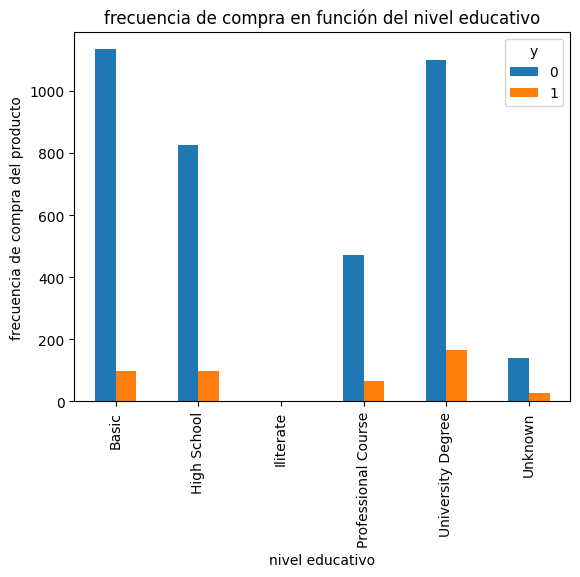

In [15]:
pd.crosstab(data['education'], data['y']).plot(kind = 'bar')
plt.title('frecuencia de compra en función del nivel educativo')
plt.xlabel('nivel educativo')
plt.ylabel('frecuencia de compra del producto')

In [16]:
data.education

0                   Basic
1             High School
2             High School
3                   Basic
4       University Degree
              ...        
4114                Basic
4115          High School
4116          High School
4117          High School
4118          High School
Name: education, Length: 4119, dtype: object

In [17]:
np.sum((data['education'] == 'Basic') & (data['y'] == 1))

98

In [18]:
np.sum((data['education'] == 'Basic') & (data['y'] == 0))

1133

Text(0, 0.5, 'Nivel de compras')

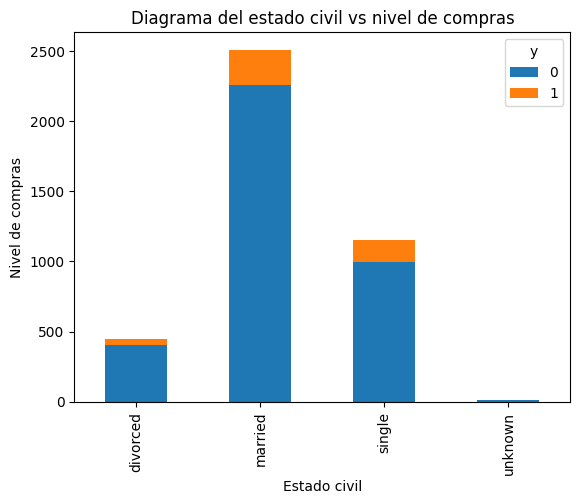

In [19]:
table_0 = pd.crosstab(data['marital'], data['y'])
table_0.plot(kind = 'bar', stacked = True)
plt.title('Diagrama del estado civil vs nivel de compras')
plt.xlabel('Estado civil')
plt.ylabel('Nivel de compras')

Text(0, 0.5, 'Nivel de compras')

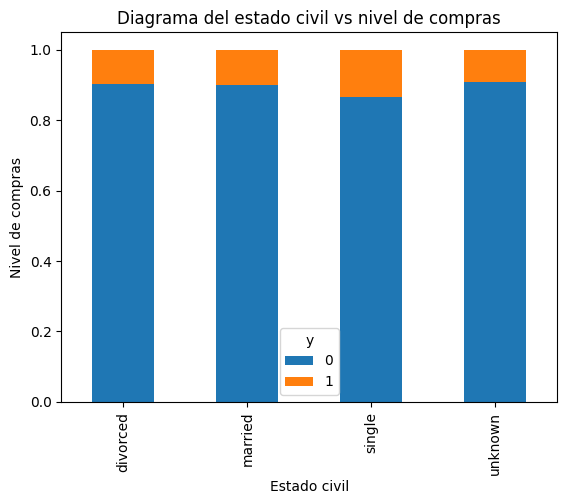

In [20]:
# Ahora, la misma información en términos de proporción:

table_0.div(table_0.sum(1).astype(float), axis = 0).plot(kind = 'bar', stacked = True)
plt.title('Diagrama del estado civil vs nivel de compras')
plt.xlabel('Estado civil')
plt.ylabel('Nivel de compras')

In [21]:
table_0.head()

y,0,1
marital,,
divorced,403,43
married,2257,252
single,998,155
unknown,10,1


Text(0, 0.5, 'Nivel de compras')

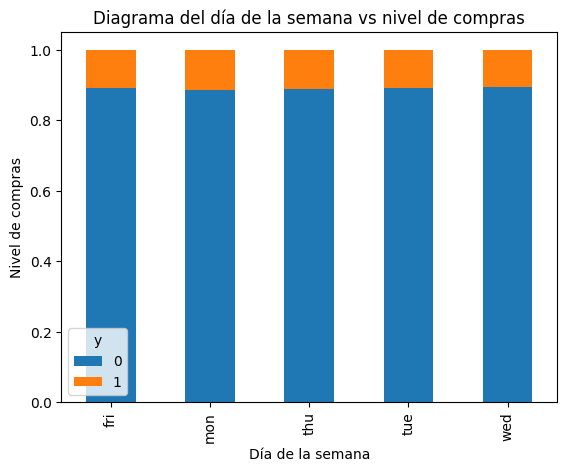

In [22]:
# Veamos si el día de la semana puede influir en la compra:

table_1 = pd.crosstab(data['day_of_week'], data['y'])
table_1.div(table_1.sum(1).astype(float), axis = 0).plot(kind = 'bar', stacked = True)
plt.title('Diagrama del día de la semana vs nivel de compras')
plt.xlabel('Día de la semana')
plt.ylabel('Nivel de compras')

Text(0, 0.5, 'Nivel de compras')

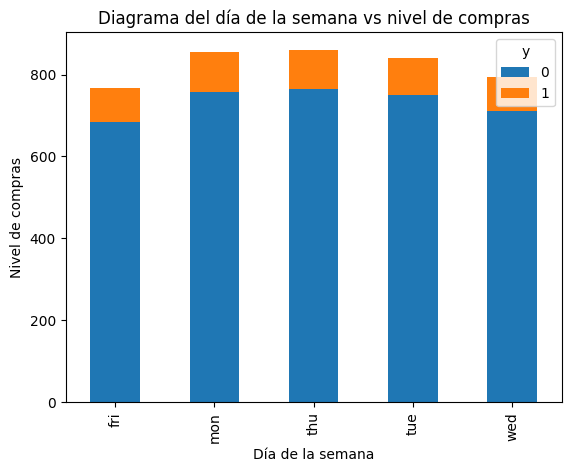

In [23]:
table_1 = pd.crosstab(data['day_of_week'], data['y'])
table_1.plot(kind = 'bar', stacked = True)
plt.title('Diagrama del día de la semana vs nivel de compras')
plt.xlabel('Día de la semana')
plt.ylabel('Nivel de compras')

Text(0, 0.5, 'Nivel de compras')

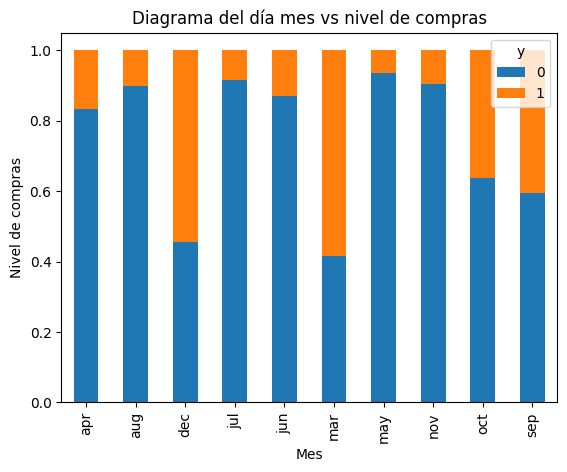

In [24]:
# Influye el mes?

table_3 = pd.crosstab(data['month'], data['y'])
table_3.div(table_3.sum(1).astype(float), axis = 0). plot(kind = 'bar', stacked = True)
plt.title('Diagrama del día mes vs nivel de compras')
plt.xlabel('Mes')
plt.ylabel('Nivel de compras')

Text(0, 0.5, 'Nivel de compras')

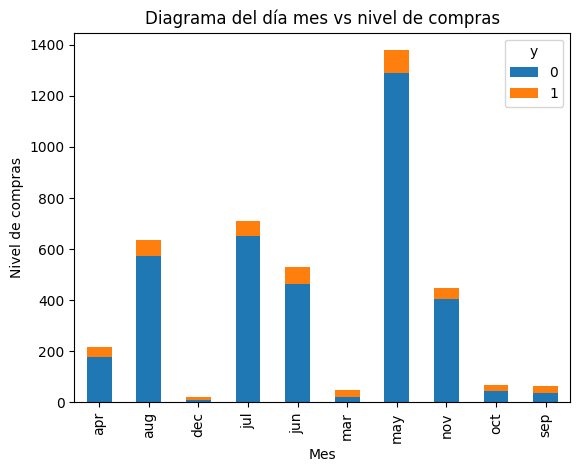

In [25]:
table_3 = pd.crosstab(data['month'], data['y'])
table_3.plot(kind = 'bar', stacked = True)
plt.title('Diagrama del día mes vs nivel de compras')
plt.xlabel('Mes')
plt.ylabel('Nivel de compras')

Text(0, 0.5, 'Número de clientes')

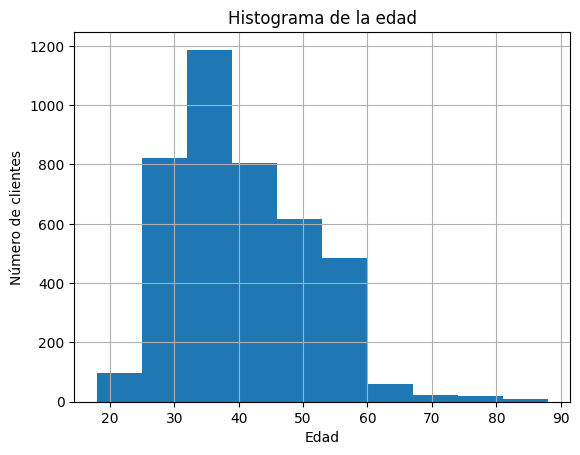

In [26]:
data['age'].hist()
plt.title('Histograma de la edad')
plt.xlabel('Edad')
plt.ylabel('Número de clientes')

<Axes: xlabel='age'>

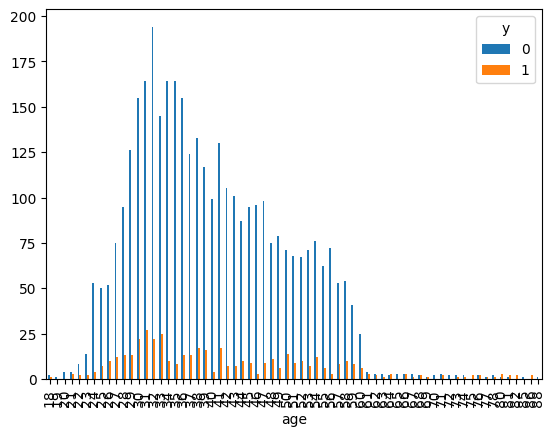

In [27]:
pd.crosstab(data['age'], data['y']).plot(kind = 'bar')

## Conversión de las variables categóricas a dummies:

In [28]:
# Creamos una lista con las variables categóricas a transformar:

categories = ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'poutcome']

# Creamos un bucle for para crear las variables dummies:

for category in categories:
    cat_prefix = 'cat_' + category
    cat_dummies = pd.get_dummies(data[category], prefix = cat_prefix)
    data = data.join(cat_dummies)

In [29]:
data.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,cat_month_oct,cat_month_sep,cat_day_of_week_fri,cat_day_of_week_mon,cat_day_of_week_thu,cat_day_of_week_tue,cat_day_of_week_wed,cat_poutcome_failure,cat_poutcome_nonexistent,cat_poutcome_success
0,30,blue-collar,married,Basic,no,yes,no,cellular,may,fri,...,0,0,1,0,0,0,0,0,1,0
1,39,services,single,High School,no,no,no,telephone,may,fri,...,0,0,1,0,0,0,0,0,1,0
2,25,services,married,High School,no,yes,no,telephone,jun,wed,...,0,0,0,0,0,0,1,0,1,0
3,38,services,married,Basic,no,unknown,unknown,telephone,jun,fri,...,0,0,1,0,0,0,0,0,1,0
4,47,admin.,married,University Degree,no,yes,no,cellular,nov,mon,...,0,0,0,1,0,0,0,0,1,0


In [30]:
pd.DataFrame(data.columns.values)

,0
0,age
1,job
2,marital
3,education
4,default
...,...
67,cat_day_of_week_tue
68,cat_day_of_week_wed
69,cat_poutcome_failure
70,cat_poutcome_nonexistent


In [31]:
data.shape

(4119, 72)

In [32]:
# De aquí saldrá un nuevo dataframe data_0 al cuál se le eliminarán columnas que ya no interesan

data_0 = data
data_0.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,cat_month_oct,cat_month_sep,cat_day_of_week_fri,cat_day_of_week_mon,cat_day_of_week_thu,cat_day_of_week_tue,cat_day_of_week_wed,cat_poutcome_failure,cat_poutcome_nonexistent,cat_poutcome_success
0,30,blue-collar,married,Basic,no,yes,no,cellular,may,fri,...,0,0,1,0,0,0,0,0,1,0
1,39,services,single,High School,no,no,no,telephone,may,fri,...,0,0,1,0,0,0,0,0,1,0
2,25,services,married,High School,no,yes,no,telephone,jun,wed,...,0,0,0,0,0,0,1,0,1,0
3,38,services,married,Basic,no,unknown,unknown,telephone,jun,fri,...,0,0,1,0,0,0,0,0,1,0
4,47,admin.,married,University Degree,no,yes,no,cellular,nov,mon,...,0,0,0,1,0,0,0,0,1,0


In [33]:
# Comenzamos a trabajar con data_0:

data_vars = data_0.columns.values.tolist() # Creamos una lista con los nombres de cada columna
vars_to_keep = [v for v in data_vars if v not in categories] # Creamos una lista con los nombres de las columnas finales

# Creamos uno nuevo dataframe, dónde ya aparecerán solamente las variables de interés:

data_bank = data_0[vars_to_keep]
data_bank.head()

,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,...,cat_month_oct,cat_month_sep,cat_day_of_week_fri,cat_day_of_week_mon,cat_day_of_week_thu,cat_day_of_week_tue,cat_day_of_week_wed,cat_poutcome_failure,cat_poutcome_nonexistent,cat_poutcome_success
0,30,487,2,999,0,-1.8,92.893,-46.2,1.313,5099.1,...,0,0,1,0,0,0,0,0,1,0
1,39,346,4,999,0,1.1,93.994,-36.4,4.855,5191.0,...,0,0,1,0,0,0,0,0,1,0
2,25,227,1,999,0,1.4,94.465,-41.8,4.962,5228.1,...,0,0,0,0,0,0,1,0,1,0
3,38,17,3,999,0,1.4,94.465,-41.8,4.959,5228.1,...,0,0,1,0,0,0,0,0,1,0
4,47,58,1,999,0,-0.1,93.200,-42.0,4.191,5195.8,...,0,0,0,1,0,0,0,0,1,0


In [34]:
data_bank['y'].unique()

array([0, 1])

In [35]:
data_bank['y'].head()

0    0
1    0
2    0
3    0
4    0
Name: y, dtype: int64

In [36]:
data_bank.columns.values

array(['age', 'duration', 'campaign', 'pdays', 'previous', 'emp.var.rate',
       'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed', 'y',
       'cat_job_admin.', 'cat_job_blue-collar', 'cat_job_entrepreneur',
       'cat_job_housemaid', 'cat_job_management', 'cat_job_retired',
       'cat_job_self-employed', 'cat_job_services', 'cat_job_student',
       'cat_job_technician', 'cat_job_unemployed', 'cat_job_unknown',
       'cat_marital_divorced', 'cat_marital_married',
       'cat_marital_single', 'cat_marital_unknown', 'cat_education_Basic',
       'cat_education_High School', 'cat_education_Iliterate',
       'cat_education_Professional Course',
       'cat_education_University Degree', 'cat_education_Unknown',
       'cat_default_no', 'cat_default_unknown', 'cat_default_yes',
       'cat_housing_no', 'cat_housing_unknown', 'cat_housing_yes',
       'cat_loan_no', 'cat_loan_unknown', 'cat_loan_yes',
       'cat_contact_cellular', 'cat_contact_telephone', 'cat_month_apr',


In [37]:
data_bank.shape

(4119, 62)

In [38]:
# Vamos creando los conjuntos de variables para crear nuestro modelo de regresión logística

data_bank_vars = data_bank.columns.values.tolist()

Y = ['y']
X = [v for v in data_bank_vars if v not in Y]

### Seleccción de rasgos para el modelo

In [39]:
from sklearn import datasets
from sklearn.feature_selection import RFE
from sklearn.linear_model import LogisticRegression

In [40]:
n = 12 # Éste será el número de variables predictoras con el que trabajaremos:

X_0 = pd.DataFrame(data_bank[X])
Y_0 = pd.DataFrame(data_bank[Y])

In [41]:
lr = LogisticRegression() # lr = logistic regression
rfe = RFE(lr, n_features_to_select = n)
rfe.fit(X_0, Y_0)

/usr/local/lib/python3.10/dist-packages/sklearn/utils/validation.py:1143: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_logistic.py:458: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.10/dist-packages/sklearn/utils/validation.py:1143: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel

RFE(estimator=LogisticRegression(), n_features_to_select=12)

In [42]:
print(rfe.support_)

[False False False False  True False False False  True False False False
 False False False  True False False  True False  True False False False
 False False False False False False False False False False False False
 False False False False False False False False False  True  True  True
  True  True False False False False False False False False  True False
  True]


In [43]:
print(rfe.ranking_)

[30 43 18 46  1 17 26 22  1 37  3 12  8 41 11  1  9 24  1  2  1 47 16 35
 29 49 25 13 48 19 27  5 34 28 50  6 15 45 14 20 36  7  4 40 21  1  1  1
  1  1 23 39 44 42 38 32 33 10  1 31  1]


In [44]:
print(len(X))
print(len(rfe.support_))
print(len(rfe.ranking_))

61
61
61


In [45]:
z = zip(X, rfe.support_, rfe.ranking_)
list(z)

[('age', False, 30),
 ('duration', False, 43),
 ('campaign', False, 18),
 ('pdays', False, 46),
 ('previous', True, 1),
 ('emp.var.rate', False, 17),
 ('cons.price.idx', False, 26),
 ('cons.conf.idx', False, 22),
 ('euribor3m', True, 1),
 ('nr.employed', False, 37),
 ('cat_job_admin.', False, 3),
 ('cat_job_blue-collar', False, 12),
 ('cat_job_entrepreneur', False, 8),
 ('cat_job_housemaid', False, 41),
 ('cat_job_management', False, 11),
 ('cat_job_retired', True, 1),
 ('cat_job_self-employed', False, 9),
 ('cat_job_services', False, 24),
 ('cat_job_student', True, 1),
 ('cat_job_technician', False, 2),
 ('cat_job_unemployed', True, 1),
 ('cat_job_unknown', False, 47),
 ('cat_marital_divorced', False, 16),
 ('cat_marital_married', False, 35),
 ('cat_marital_single', False, 29),
 ('cat_marital_unknown', False, 49),
 ('cat_education_Basic', False, 25),
 ('cat_education_High School', False, 13),
 ('cat_education_Iliterate', False, 48),
 ('cat_education_Professional Course', False, 19),
 

In [46]:
# Seleccionamos las variables True, 1

cols = ['previous', 'euribor3m', 'cat_job_retired', 'cat_job_student',
        'cat_job_unemployed', 'cat_month_dec', 'cat_month_jul', 'cat_month_jun',
        'cat_month_mar', 'cat_month_may', 'cat_poutcome_failure', 'cat_poutcome_success']

In [47]:
X_1 = data_bank[cols]
Y_1 = data_bank['y']

# Implementación del modelo con statsmodel.api

In [48]:
import statsmodels.api as sm

In [49]:
logit_model = sm.Logit(Y_1, X_1)

In [50]:
result = logit_model.fit()

Optimization terminated successfully.
         Current function value: 0.279611
         Iterations 7


In [51]:
result.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:                      y   No. Observations:                 4119
Model:                          Logit   Df Residuals:                     4107
Method:                           MLE   Df Model:                           11
Date:                Sun, 12 Nov 2023   Pseudo R-squ.:                  0.1906
Time:                        22:26:36   Log-Likelihood:                -1151.7
converged:                       True   LL-Null:                       -1422.9
Covariance Type:            nonrobust   LLR p-value:                2.858e-109
========================================================================================
                           coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------
previous                 0.3549      0.141      2.513      0.012       0.078       0.632
euribor3m               -0.6330      0.026    -24.082      0.000      -0.684      -0.581
cat_job_retired          0.0820      0.220      0.372      0.710      -0.350       0.514
cat_job_student         -0.0169      0.294     -0.057      0.954      -0.592       0.559
cat_job_unemployed       0.1552      0.302      0.514      0.607      -0.437       0.747
cat_month_dec            0.6520      0.466      1.398      0.162      -0.262       1.566
cat_month_jul            0.3282      0.184      1.786      0.074      -0.032       0.688
cat_month_jun            0.3270      0.169      1.935      0.053      -0.004       0.658
cat_month_mar            1.0340      0.315      3.278      0.001       0.416       1.652
cat_month_may           -1.0635      0.126     -8.439      0.000      -1.311      -0.816
cat_poutcome_failure    -1.0701      0.246     -4.344      0.000      -1.553      -0.587
cat_poutcome_success     0.7554      0.289      2.615      0.009       0.189       1.321
========================================================================================
"""

In [52]:
result.summary2()

<class 'statsmodels.iolib.summary2.Summary'>
"""
                           Results: Logit
=====================================================================
Model:               Logit             Method:            MLE        
Dependent Variable:  y                 Pseudo R-squared:  0.191      
Date:                2023-11-12 22:26  AIC:               2327.4362  
No. Observations:    4119              BIC:               2403.3166  
Df Model:            11                Log-Likelihood:    -1151.7    
Df Residuals:        4107              LL-Null:           -1422.9    
Converged:           1.0000            LLR p-value:       2.8578e-109
No. Iterations:      7.0000            Scale:             1.0000     
---------------------------------------------------------------------
                      Coef.  Std.Err.    z     P>|z|   [0.025  0.975]
---------------------------------------------------------------------
previous              0.3549   0.1413   2.5126 0.0120  0.0781  0.6318
euribor3m            -0.6330   0.0263 -24.0815 0.0000 -0.6845 -0.5814
cat_job_retired       0.0820   0.2203   0.3723 0.7097 -0.3497  0.5137
cat_job_student      -0.0169   0.2937  -0.0575 0.9541 -0.5924  0.5587
cat_job_unemployed    0.1552   0.3021   0.5139 0.6073 -0.4368  0.7473
cat_month_dec         0.6520   0.4664   1.3978 0.1622 -0.2622  1.5661
cat_month_jul         0.3282   0.1838   1.7855 0.0742 -0.0321  0.6884
cat_month_jun         0.3270   0.1690   1.9352 0.0530 -0.0042  0.6582
cat_month_mar         1.0340   0.3155   3.2776 0.0010  0.4157  1.6524
cat_month_may        -1.0635   0.1260  -8.4385 0.0000 -1.3105 -0.8165
cat_poutcome_failure -1.0701   0.2463  -4.3443 0.0000 -1.5528 -0.5873
cat_poutcome_success  0.7554   0.2888   2.6155 0.0089  0.1893  1.3215
=====================================================================

"""

# Implementación del modelo con scikit-learn

In [53]:
from sklearn import linear_model # con linear_model podemos trabajar la regresión logística

In [54]:
logit_model2 = linear_model.LogisticRegression()

In [55]:
logit_model2.fit(X_1, Y_1)

LogisticRegression()

In [56]:
logit_model2.score(X_1, Y_1)

0.9026462733673222

In [57]:
Y_1.mean()

0.10949259529011895

In [58]:
1 - Y_1.mean()

0.8905074047098811

In [59]:
pd.DataFrame(list(zip(X_1.columns, np.transpose(logit_model2.coef_))))

,0,1
0,previous,[0.3933522416773198]
1,euribor3m,[-0.5020960568413431]
2,cat_job_retired,[0.31723204398153176]
3,cat_job_student,[0.20128275884128774]
4,cat_job_unemployed,[0.2793187319783783]
5,cat_month_dec,[0.7938596310499624]
6,cat_month_jul,[0.3612411704729884]
7,cat_month_jun,[0.48107825443126273]
8,cat_month_mar,[1.221813498405123]
9,cat_month_may,[-0.7512150878481727]


# Validación del modelo

In [60]:
from sklearn.model_selection import train_test_split

In [61]:
X_train, X_test, Y_train, Y_test = train_test_split(X_1, Y_1, test_size = 0.3, random_state = 0)

In [62]:
logit_model3 = linear_model.LogisticRegression()
logit_model3.fit(X_train, Y_train)

LogisticRegression()

In [63]:
probs = logit_model3.predict_proba(X_test)

In [64]:
probs

array([[0.93699338, 0.06300662],
       [0.88536858, 0.11463142],
       [0.91972308, 0.08027692],
       ...,
       [0.71727505, 0.28272495],
       [0.97925302, 0.02074698],
       [0.25827148, 0.74172852]])

In [65]:
prediction = logit_model3.predict(X_test)

In [66]:
prediction

array([0, 0, 0, ..., 0, 0, 1])

In [67]:
from sklearn import metrics

In [68]:
# Con el siguiente comando, vemos el porcentaje de eficacia de nuetro modelo respecto al Y de prueba:
metrics.accuracy_score(Y_test, prediction)

0.9061488673139159

## Nota:

#### Del array `probs`, la columna izquierda se refiere a la probabilidad igual a 0, y la columna de la derecha a la probabilidad igual a 1. Para las predicciones, tomamos la columna de la derecha; si el número en cuestión es >= 0.5, se aproxima a 1. Si es < 0.5, se aproxima a cero. Este número de referencia 0.5, puede cambiarse.

In [69]:
probs[:, 1]

array([0.06300662, 0.11463142, 0.08027692, ..., 0.28272495, 0.02074698,
       0.74172852])

In [110]:
prob_0 = probs[:, 1]
prob_0_df = pd.DataFrame(prob_0)
threshold = 0.1
prob_0_df['prediction'] = np.where(prob_0_df[0] > threshold, 1, 0)
prob_0_df.head()

,0,prediction
0,0.063007,0
1,0.114631,1
2,0.080277,0
3,0.059913,0
4,0.064444,0


In [111]:
prob_0

array([0.06300662, 0.11463142, 0.08027692, ..., 0.28272495, 0.02074698,
       0.74172852])

In [118]:
pd.crosstab(prob_0_df['prediction'], columns = 'count')

col_0,count
prediction,
0,887
1,349


In [ ]:
(349 / (887 + 349)) * 100

28.236245954692556

In [ ]:
(349 / len(prob_0_df)) * 100

28.236245954692556

## Nota:

#### El umbral (threshold) puede modificarse; en este último ejemplo hemos hecho una modificación un tanto "agresiva". Podríamos probar con por ejemplo, threshold = 0.15.

# Validación Cruzada (Cross Validation)

In [119]:
from sklearn.model_selection import cross_val_score

In [120]:
scores = cross_val_score(linear_model.LogisticRegression(), X_1, Y_1, scoring = 'accuracy', cv = 10)

In [121]:
scores

array([0.9223301 , 0.90048544, 0.90291262, 0.89563107, 0.90533981,
       0.90533981, 0.8907767 , 0.89563107, 0.89805825, 0.90024331])

In [122]:
scores.mean()

0.9016748163371364

# Matrices de confusión y curvas ROC

In [74]:
X_train, X_test, Y_train, Y_test = train_test_split(X_1, Y_1, test_size = 0.3, random_state = 0)

In [75]:
logit_model4 = linear_model.LogisticRegression()
logit_model4.fit(X_train, Y_train)

LogisticRegression()

In [76]:
probs = logit_model4.predict_proba(X_test)

In [77]:
probs

array([[0.93699338, 0.06300662],
       [0.88536858, 0.11463142],
       [0.91972308, 0.08027692],
       ...,
       [0.71727505, 0.28272495],
       [0.97925302, 0.02074698],
       [0.25827148, 0.74172852]])

In [102]:
probs[:, 1]

array([0.06300662, 0.11463142, 0.08027692, ..., 0.28272495, 0.02074698,
       0.74172852])

In [103]:
prob_1_df = pd.DataFrame(probs[:, 1])
prob_1_df

,0
0,0.063007
1,0.114631
2,0.080277
3,0.059913
4,0.064444
...,...
1231,0.059913
1232,0.059855
1233,0.282725
1234,0.020747


In [104]:
threshold_1 = 0.1

In [81]:
Y_test # Observar los índices

3754    0
45      0
2774    0
1170    0
4042    0
       ..
1728    0
1460    0
1363    0
1898    0
3519    1
Name: y, Length: 1236, dtype: int64

In [105]:
prob_1_df['prediction'] = np.where(prob_1_df[0] >= threshold_1, 1, 0)
prob_1_df['actual'] = list(Y_test) # Debe hacerse así, para eliminar viejos índices y asociarse con el nuevo df
prob_1_df

,0,prediction,actual
0,0.063007,0,0
1,0.114631,1,0
2,0.080277,0,0
3,0.059913,0,0
4,0.064444,0,0
...,...,...,...
1231,0.059913,0,0
1232,0.059855,0,0
1233,0.282725,1,0
1234,0.020747,0,0


In [106]:
confussion_matrix = pd.crosstab(prob_1_df['prediction'], prob_1_df['actual'])

In [107]:
confussion_matrix

actual,0,1
prediction,,
0,842,45
1,272,77


In [85]:
'''
tn = verdaderos negativos
tp = verdaderos positivos
fn = falsos negativos
fp = falsos positivos
'''
tn = confussion_matrix[0][0]
tp = confussion_matrix[1][1]
fn = confussion_matrix[1][0]
fp = confussion_matrix[0][1]

In [86]:
# sensibilidad = verdaderos positivos / (verdaderos positivos + falsos positivos)

sens = tp / (tp + fn)
sens

0.6311475409836066

In [87]:
# especifidad_1 = 1 - tn / (tn + fp)

esp_1 = 1 - tn / (tn + fp)
esp_1

0.24416517055655296

In [108]:
threshold_list = [0.04, 0.06, 0.08, 0.1, 0.12, 0.14, 0.16, 0.18, 0.2, 0.5]

sensitivities = [1]
especifities_1 = [1]

for i in range(len(threshold_list)):
    prob_1_df['prediction'] = np.where(prob_1_df[0] >= threshold_list[i], 1, 0)
    prob_1_df['actual'] = list(Y_test) # Debe hacerse así, para eliminar viejos índices y asociarse con el nuevo df
    prob_1_df.head()

    confussion_matrix = pd.crosstab(prob_1_df['prediction'], prob_1_df['actual'])

    tn = confussion_matrix[0][0]
    tp = confussion_matrix[1][1]
    fn = confussion_matrix[1][0]
    fp = confussion_matrix[0][1]

    sens = tp / (tp + fn)
    sensitivities.append(sens)

    esp_1 = 1 - tn / (tn + fp)
    especifities_1.append(esp_1)

sensitivities.append(0), especifities_1.append(0)

(None, None)

In [89]:
import matplotlib.pyplot as plt

Text(0.5, 1.0, 'Curva ROC')

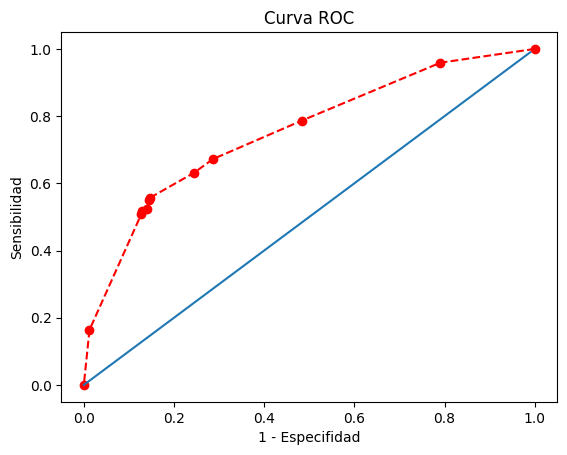

In [90]:
plt.plot(especifities_1, sensitivities, marker ='o', linestyle = '--', color = 'r')
x = [i * 0.01 for i in range(100)]
y = [i * 0.01 for i in range(100)]
plt.plot(x, y)
plt.xlabel('1 - Especifidad')
plt.ylabel('Sensibilidad')
plt.title('Curva ROC')

In [91]:
from sklearn import metrics

In [92]:
probs_1 = probs[:, 1]

In [93]:
probs_1

array([0.06300662, 0.11463142, 0.08027692, ..., 0.28272495, 0.02074698,
       0.74172852])

In [94]:
especif_1, sensit, _ = metrics.roc_curve(Y_test, probs_1)

In [95]:
especif_1

array([0.        , 0.        , 0.        , 0.        , 0.        ,
       0.00179533, 0.00179533, 0.002693  , 0.002693  , 0.005386  ,
       0.005386  , 0.00718133, 0.00897666, 0.00897666, 0.00987433,
       0.00987433, 0.01256732, 0.01256732, 0.01436266, 0.01436266,
       0.01885099, 0.02064632, 0.02333932, 0.02333932, 0.02423698,
       0.02423698, 0.02603232, 0.02603232, 0.02962298, 0.02962298,
       0.03321364, 0.03321364, 0.03500898, 0.03590664, 0.03859964,
       0.04129264, 0.04219031, 0.04308797, 0.04667864, 0.04667864,
       0.0502693 , 0.0502693 , 0.05206463, 0.05206463, 0.06014363,
       0.06193896, 0.06732496, 0.06732496, 0.06912029, 0.07091562,
       0.07181329, 0.07360862, 0.07630162, 0.07630162, 0.07719928,
       0.07719928, 0.07809695, 0.07809695, 0.08168761, 0.08348294,
       0.08438061, 0.08438061, 0.08707361, 0.08797127, 0.08976661,
       0.10502693, 0.11041293, 0.11310592, 0.11310592, 0.11400359,
       0.12028725, 0.12028725, 0.12118492, 0.12208259, 0.12387

In [96]:
sensit

array([0.        , 0.00819672, 0.01639344, 0.03278689, 0.04918033,
       0.04918033, 0.08196721, 0.08196721, 0.09016393, 0.09016393,
       0.09836066, 0.09836066, 0.09836066, 0.10655738, 0.1147541 ,
       0.13114754, 0.13114754, 0.16393443, 0.16393443, 0.21311475,
       0.21311475, 0.21311475, 0.21311475, 0.2295082 , 0.2295082 ,
       0.23770492, 0.23770492, 0.24590164, 0.24590164, 0.26229508,
       0.26229508, 0.2704918 , 0.2704918 , 0.30327869, 0.31147541,
       0.31147541, 0.3442623 , 0.35245902, 0.35245902, 0.36065574,
       0.36065574, 0.37704918, 0.37704918, 0.3852459 , 0.3852459 ,
       0.3852459 , 0.3852459 , 0.39344262, 0.39344262, 0.39344262,
       0.40163934, 0.40163934, 0.40163934, 0.41803279, 0.41803279,
       0.42622951, 0.42622951, 0.43442623, 0.43442623, 0.43442623,
       0.43442623, 0.45081967, 0.45081967, 0.45901639, 0.45901639,
       0.47540984, 0.47540984, 0.47540984, 0.48360656, 0.49180328,
       0.49180328, 0.5       , 0.50819672, 0.50819672, 0.50819

In [97]:
data_f = pd.DataFrame({
    'x': especif_1,
    'y': sensit
})

In [98]:
data_f.head()

,x,y
0,0.0,0.000000
1,0.0,0.008197
2,0.0,0.016393
3,0.0,0.032787
4,0.0,0.049180


Text(0.5, 1.0, 'Curva ROC')

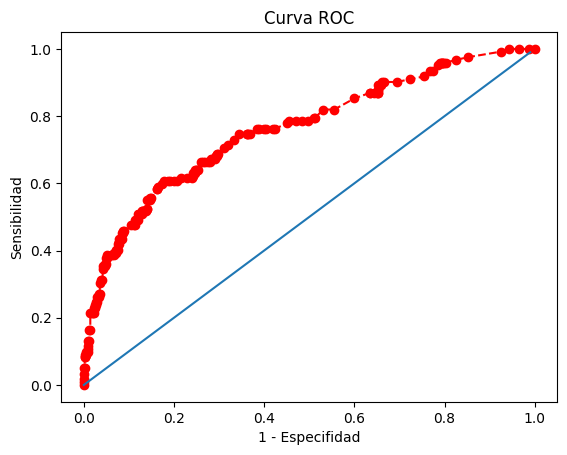

In [99]:
plt.plot(data_f['x'], data_f['y'], marker ='o', linestyle = '--', color = 'r')
x = [i * 0.01 for i in range(100)]
y = [i * 0.01 for i in range(100)]
plt.plot(x, y)
plt.xlabel('1 - Especifidad')
plt.ylabel('Sensibilidad')
plt.title('Curva ROC')

In [100]:
# auc = área bajo la curva (area under curve)
auc = metrics.auc(especif_1, sensit)

In [101]:
auc

0.7624974247284928